# Red Neuronal
### Limpieza de datos
1. Leemos el dataset con pandas
2. Revision del dataframe
3. Revisar los tipos de datos
4. Eliminar valores duplicado y valores nulos
5. Reemplazar datos faltantes.
6. Limpiar todas las columnas numericas y objeto
7. Revisar datos categoricos
8. Detectar valores fuera de rango
9. Deteccion de Outliers con IQR (metodos estadisticos)
10. Comprobar el balanceo de datos
Si hay datos desbalanceados la neurona no aprende adecuadamente.
11. Estandarizar los datos
edad 3 - 103 -> 3+103/2 = 106/2 = 53 X
34-80
12. Division de datos de entrenamiento y prueba
13. Creamos el modelo

In [13]:
import pandas as pd
#URL = "https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv"

ruta = r"C:\Users\pumas\OneDrive\Documents\Portafolio-Diplomado\tarea_df_grafica\macrodata.csv"
df = pd.read_csv(ruta)
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,fecha
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,1959-01-01
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,1959-04-01
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,1959-07-01
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,1959-10-01
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,1960-01-01


In [14]:
#importamos las librerias
import numpy as np
import matplotlib.pyplot as plt # crear graficas
#sklearn sirve para realizar el prepocesamiento
from sklearn.model_selection import train_test_split #division de datos de entrenamiento y prueba
#Estandarizacion de datos
from sklearn.preprocessing import StandardScaler, LabelEncoder
#OneHotEncoder
#Matriz de confusion
from sklearn.metrics import confusion_matrix,classification_report
#Sirve para clasificacion
"""
TP = Verdaderos Positivos
TN = Verdaderos Negativos
FP = Falsos Positivos
FN = Falsos Negativos
Reporte de clasificacion Accuracy, Sensibility, AUC
"""

'\nTP = Verdaderos Positivos\nTN = Verdaderos Negativos\nFP = Falsos Positivos\nFN = Falsos Negativos\nReporte de clasificacion Accuracy, Sensibility, AUC\n'

In [15]:
#cargar las librerias para el modelo de deep learning
from tensorflow.keras.models import Sequential #Guardamos cada capa del modelo
from tensorflow.keras.layers import Dense #Creamos las neuronas

In [17]:
#Obtener el tamaño completo del dataset
df.shape

(203, 15)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      203 non-null    float64
 1   quarter   203 non-null    float64
 2   realgdp   203 non-null    float64
 3   realcons  203 non-null    float64
 4   realinv   203 non-null    float64
 5   realgovt  203 non-null    float64
 6   realdpi   203 non-null    float64
 7   cpi       203 non-null    float64
 8   m1        203 non-null    float64
 9   tbilrate  203 non-null    float64
 10  unemp     203 non-null    float64
 11  pop       203 non-null    float64
 12  infl      203 non-null    float64
 13  realint   203 non-null    float64
 14  fecha     203 non-null    str    
dtypes: float64(14), str(1)
memory usage: 23.9 KB


In [19]:
#Exploramos dataset
df.describe()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
count,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000
mean,1983.876847,2.492611,7221.171901,4825.293103,1012.863862,663.328640,5310.540887,105.075788,667.927586,5.311773,5.884729,239.724153,3.961330,1.336502
std,14.686817,1.118563,3214.956044,2313.346192,585.102267,140.863655,2423.515977,61.278878,455.346381,2.803071,1.458574,37.390450,3.253216,2.668799
min,1959.000000,1.000000,2710.349000,1707.400000,259.764000,460.400000,1886.900000,28.980000,139.600000,0.120000,3.400000,177.146000,-8.790000,-6.790000
25%,1971.000000,1.500000,4440.103500,2874.100000,519.147500,527.959500,3276.950000,41.050000,228.650000,3.515000,4.900000,208.631000,2.270000,-0.085000
50%,1984.000000,2.000000,6559.594000,4299.900000,896.210000,662.412000,4959.400000,104.100000,540.900000,5.010000,5.700000,236.348000,3.240000,1.340000
75%,1996.500000,3.000000,9629.346500,6398.150000,1436.681500,773.049000,6977.850000,159.650000,1102.100000,6.665000,6.800000,271.721500,4.975000,2.630000
max,2009.000000,4.000000,13415.266000,9363.600000,2264.721000,1044.088000,10077.500000,218.610000,1673.900000,15.330000,10.700000,308.013000,14.620000,10.950000


In [ ]:
print(df['quarter'].unique()) #Ver si las etiquetas son unicas

[1. 2. 3. 4.]


In [27]:
print(df['quarter'].value_counts())

quarter
1.0    51
2.0    51
3.0    51
4.0    50
Name: count, dtype: int64


In [28]:
#Limpieza de datos
#Buscar valores faltantes
print(df.isnull().sum())

year        0
quarter     0
realgdp     0
realcons    0
realinv     0
realgovt    0
realdpi     0
cpi         0
m1          0
tbilrate    0
unemp       0
pop         0
infl        0
realint     0
fecha       0
dtype: int64


In [29]:
#Buscar duplicados
print(df.duplicated().sum()) #contamos cantidad de duplicados
df = df.drop_duplicates() #eliminamos duplicados
print(df.duplicated().sum())

0
0


In [30]:
#Usamos la media para los valores faltantes
columnas_num = df.select_dtypes(include=np.number).columns
df[columnas_num] = df[columnas_num].fillna(df[columnas_num].mean())

In [31]:
print(df.isnull().sum())
print(df.duplicated().sum())

year        0
quarter     0
realgdp     0
realcons    0
realinv     0
realgovt    0
realdpi     0
cpi         0
m1          0
tbilrate    0
unemp       0
pop         0
infl        0
realint     0
fecha       0
dtype: int64
0


In [32]:
X = df.drop("quarter", axis = 1)
y = df["quarter"]
print(X.head())
print(y.head())

     year   realgdp  realcons  realinv  realgovt  realdpi    cpi     m1  \
0  1959.0  2710.349    1707.4  286.898   470.045   1886.9  28.98  139.7   
1  1959.0  2778.801    1733.7  310.859   481.301   1919.7  29.15  141.7   
2  1959.0  2775.488    1751.8  289.226   491.260   1916.4  29.35  140.5   
3  1959.0  2785.204    1753.7  299.356   484.052   1931.3  29.37  140.0   
4  1960.0  2847.699    1770.5  331.722   462.199   1955.5  29.54  139.6   

   tbilrate  unemp      pop  infl  realint       fecha  
0      2.82    5.8  177.146  0.00     0.00  1959-01-01  
1      3.08    5.1  177.830  2.34     0.74  1959-04-01  
2      3.82    5.3  178.657  2.74     1.09  1959-07-01  
3      4.33    5.6  179.386  0.27     4.06  1959-10-01  
4      3.50    5.2  180.007  2.31     1.19  1960-01-01  
0    1.0
1    2.0
2    3.0
3    4.0
4    1.0
Name: quarter, dtype: float64


In [ ]:
#conertir ese objeto a un dato numerico
#convertir ese dato objeto a un dato dummy
#codificar las clases
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]


In [ ]:
print(encoder.classes_)

['Setosa' 'Versicolor' 'Virginica']


In [ ]:
#Dividir datos de entrenamiento y datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(X_train.head())
print(X_test.head())
print(y_train)
print(y_test)

     sepal.length  sepal.width  petal.length  petal.width
6             4.6          3.4           1.4          0.3
128           6.4          2.8           5.6          2.1
95            5.7          3.0           4.2          1.2
44            5.1          3.8           1.9          0.4
30            4.8          3.1           1.6          0.2
     sepal.length  sepal.width  petal.length  petal.width
69            5.6          2.5           3.9          1.1
66            5.6          3.0           4.5          1.5
141           6.9          3.1           5.1          2.3
7             5.0          3.4           1.5          0.2
147           6.5          3.0           5.2          2.0
[0 2 1 0 0 1 2 2 2 2 0 2 2 2 0 1 1 0 1 0 1 0 2 1 0 1 1 2 1 0 1 2 2 0 2 2 0
 1 0 1 0 0 2 0 0 0 0 1 2 2 0 1 1 0 2 0 2 1 2 1 2 1 1 1 1 1 2 0 0 0 1 1 2 1
 2 2 0 2 1 0 2 0 2 1 1 0 1 2 0 0 2 2 2 1 2 0 2 1 2 2 0 1 1 1 1 1 0 2 1 1 0
 0 0 0 1 0 2 2 0]
[1 1 2 0 2 1 1 0 2 2 0 0 0 1 2 0 1 0 2 0 1 2 0 0 1 1 2 2 2 1]

In [ ]:
#escalado de datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
print(X_train[1])

[ 0.63982407 -0.58674247  1.04183404  1.1863645 ]


In [ ]:
#Creamos el modelo
modelo = Sequential([
    #4 de las caracteristicas
   Dense(4,activation="relu",input_shape=(4,)), #entra caracteristicas
   Dense(4,activation="relu"),
   Dense(3,activation="softmax") #sale son la prediccion de las etiquetas
])
#Mostramos la arquitectura
modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55 (220.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compilamos la red
#perdidas categoricas se ocupan cuando tenemos multiples clases
modelo.compile(optimizer = "adam",loss = "sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
#Entrenamos la red
historial = modelo.fit(X_train,y_train,epochs=100,batch_size=16,validation_split = 0.2, verbose = 1)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.4526 - loss: 1.0044 - val_accuracy: 0.5000 - val_loss: 1.0019
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4421 - loss: 0.9940 - val_accuracy: 0.5000 - val_loss: 0.9902
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4526 - loss: 0.9838 - val_accuracy: 0.5000 - val_loss: 0.9788
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4421 - loss: 0.9741 - val_accuracy: 0.5000 - val_loss: 0.9673
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4421 - loss: 0.9643 - val_accuracy: 0.5000 - val_loss: 0.9562
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4526 - loss: 0.9542 - val_accuracy: 0.5000 - val_loss: 0.9454
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4526 - loss: 0.9446 - val_accuracy: 0.5000 - val_loss: 0.9348
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4526 - loss: 0.9343 - val_accuracy: 0.5000 - val_loss

<function matplotlib.pyplot.show(close=None, block=None)>

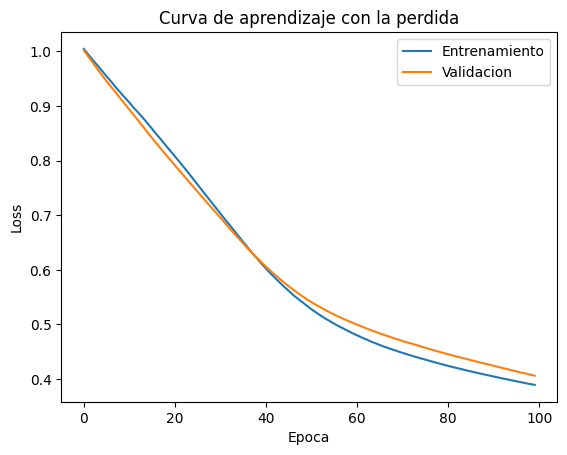

In [ ]:
#graficar el aprendizaje de la red
plt.plot(historial.history["loss"],label = "Entrenamiento")
plt.plot(historial.history["val_loss"],label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Curva de aprendizaje con la perdida")
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

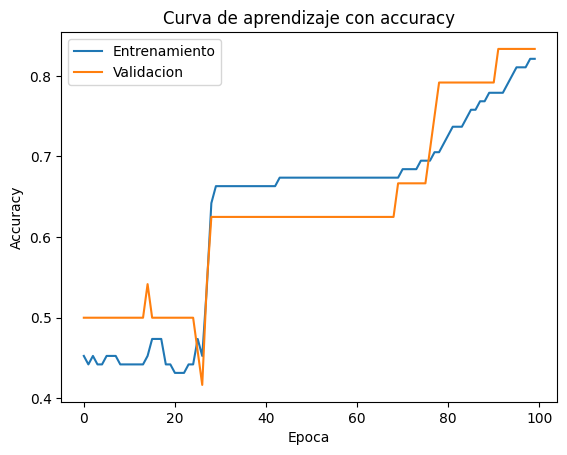

In [ ]:
plt.plot(historial.history["accuracy"],label = "Entrenamiento")
plt.plot(historial.history["val_accuracy"],label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje con accuracy")
plt.legend()
plt.show

In [ ]:
loss,accuracy = modelo.evaluate(X_test,y_test)
print("Loss",loss)
print("Accuracy",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.7333 - loss: 0.4343
Loss 0.43425843119621277
Accuracy 0.7333333492279053


In [ ]:
probabilidades = modelo.predict(X_test)
print(y_test[1])
print(probabilidades[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1
[0.03455291 0.40757403 0.5578731 ]


In [ ]:
#Encontramos la neurona que produjo el mayor valor
predicciones = np.argmax(probabilidades, axis=1)
print(predicciones)

[1 2 2 0 2 0 2 0 2 2 0 0 0 1 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 2]


In [ ]:
#Comparamos la salida real con la prediccion
resultados = pd.DataFrame({
    "Real":y_test,
    "Prediccion":predicciones
})
print(resultados)

    Real  Prediccion
0      1           1
1      1           2
2      2           2
3      0           0
4      2           2
5      1           0
6      1           2
7      0           0
8      2           2
9      2           2
10     0           0
11     0           0
12     0           0
13     1           1
14     2           2
15     0           0
16     1           2
17     0           0
18     2           2
19     0           0
20     1           2
21     2           2
22     0           0
23     0           0
24     1           2
25     1           2
26     2           2
27     2           2
28     2           2
29     1           2


In [ ]:
#Matriz de confusion
matriz = confusion_matrix(y_test,predicciones)
print(matriz)
#            ['Setosa' 'Versicolor' 'Virginica'] #salidas reales
#[Setosa]       10          0             0
#[Versicolor]    1          5             0
#[Virginica]     0          0             10
#salida predicha

[[10  0  0]
 [ 1  2  7]
 [ 0  0 10]]


In [ ]:
#Reporte de clasificacion
print(classification_report(y_test,predicciones,target_names=encoder.classes_))
#precision cuantos de los datos (ej setosa, versicolor o virginica) acerte?
#Recall de setosa, versicolor o virginica, cuantos encontre?
#F1-score que tan equilibrado esta precision y recall?

              precision    recall  f1-score   support

      Setosa       0.91      1.00      0.95        10
  Versicolor       1.00      0.20      0.33        10
   Virginica       0.59      1.00      0.74        10

    accuracy                           0.73        30
   macro avg       0.83      0.73      0.68        30
weighted avg       0.83      0.73      0.68        30



Con su dataset deberan realizar lo siguiente:
1. Preprocesamiento
2. Limpieza de datos
3. Creacion de modelo
4. Clasificacion
5. Mostrar Matriz de confusion
6. Mostrar reporte de clasificacion
si su dataset no tiene etiquetas deberan cambiarlo por otro.